# Case 1

# How do the models behave on clean data?

## Purpose of this notebook

This notebook demonstrates one of the central findings of the thesis:

> A well-calibrated model should start the test stream with a low false-positive rate. Transformer-VAE instead fits the warmup window so tightly that its rolling threshold starts miscalibrated, producing an early false-positive burst before it adapts.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **clean data** — no anomalies are injected, so every predicted 'anomaly' is by definition a false positive. This isolates each architecture's baseline calibration behavior from detection difficulty.

---

## What is being compared?

The notebook runs two variants:

| Variant | Architecture | Meaning |
|---|---|---|
| **MLP-VAE-Cyclic** | Feed-forward VAE, cyclic time features reconstructed | The thesis found this stays calibrated from the very first test-stream step. |
| **Transformer-VAE** | Attention-based VAE | The thesis found this overfits the warmup window and produces an early false-positive burst before its rolling threshold adapts. |

Both variants are trained on the same warmup window with the same window-mode streaming and rolling-threshold settings — the only difference is the encoder/decoder architecture.

## Thesis result being illustrated

The thesis found that Transformer-VAE's higher capacity lets it fit the warmup data extremely tightly, so its rolling anomaly-score threshold starts out miscalibrated and produces a burst of false positives before adapting to the true data distribution. MLP-VAE-Cyclic, with its simpler architecture, does not overfit the warmup window the same way and stays calibrated from the start.

This reduced notebook uses a shorter ERA5 period than the full thesis experiments. Therefore, the exact metric values are not expected to match the thesis. The important result is the **relative pattern between the two architectures**.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run both architecture variants on the same clean ERA5 slice.
4. Collect false-positive counts and compute the false-positive rate per architecture.
5. Compare the two architectures' calibration directly.

### Expected runtime

Window-based runs use the GPU when available and are relatively fast. Point-stream runs use CPU because they perform one update per row and do not benefit from GPU batching.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [ ]:
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


### Import and/or load Repo

In [ ]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


### Step 1 — Run the two experiment variants

#### Configuration file

The suite configuration is stored in:

```text
notebooks/cases/case01_clean_baseline_suite.yaml
```

It combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, and stream mode settings for each run — MLP-VAE-Cyclic layers in cyclic time-feature reconstruction; Transformer-VAE does not.

Both variants use the same base configuration, reduced dataset and evaluation procedure. The intended comparison is therefore the effect of **architecture choice on baseline false-positive calibration**.

#### Output Directory

During execution, the script creates a separate run directory for each variant under:

```text
runs/regression/case01_clean_baseline/
```

You may see detailed training output below. The final comparison is presented after both runs finish.

`notebooks/cases/case01_clean_baseline_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode fragments for each of the runs below (see the suite file for the exact overrides). Runs execute sequentially. Window-mode runs are batched and fast (well under a minute each on GPU). Point-mode runs stream one gradient step per row with no batching, so they run on CPU instead (faster than GPU for this access pattern) and take a few minutes each — `modules/stream/point.yaml` caps them to a 5,000-row subset for this reason.

#### Expected output

The command above trains and evaluates each configured variant. Successful completion should produce two run folders containing predictions, metrics, and diagnostic outputs.

The consolidated table below is the intended output for interpretation.

### Command:

In [3]:
!python run_regression.py notebooks/cases/case01_clean_baseline_suite.yaml \
    --session runs/regression/case01_clean_baseline

[suite] log     : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case01_clean_baseline/suite.log
[suite] suite   : /home/cohenhada/streaming-vae-anomaly-detection/notebooks/cases/case01_clean_baseline_suite.yaml
[suite] session : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case01_clean_baseline
[suite] base cfg: /home/cohenhada/streaming-vae-anomaly-detection/notebooks/cases/../../modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1]  (2 slot(s))
[suite] 2 run(s) planned:
  [  1] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite]  (module: regression.run_trial)
  [  2] TF_VAE_Clean  [case01_clean_baseline/case01_clean_baseline_suite]  (module: regression.run_trial)
[suite] START  'MLP_Cyclic_Clean'  (GPU=0)
[suite] START  'TF_VAE_Clean'  (GPU=1)
GLOBAL SEED = 42
GLOBAL SEED = 42
Logger: Verbosity=3, logging into: '/home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case01_clean_baseli

### Step 2 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table;
- anomaly-score histograms;
- an F1 comparison across variants;
- confusion-matrix summaries; and
- seed-stability diagnostics, where applicable.

These outputs are saved under:

```text
runs/regression/case01_clean_baseline/cross_compare/
```

### Command:

In [6]:
!python cross_compare.py runs/regression/case01_clean_baseline

[cross] session : runs/regression/case01_clean_baseline
[cross] output  : runs/regression/case01_clean_baseline/cross_compare
[cross] 2 run(s) found:
  MLP_Cyclic_Clean_MLP_Cyclic                         arch=MLP_Cyclic  anomaly=Clean  cyclic=False  mode=window
  TF_VAE_Clean_TF_VAE                                 arch=TF_VAE  anomaly=Clean  cyclic=False  mode=window

[cross] Loading run data ...
  MLP_Cyclic_Clean_MLP_Cyclic ... ok
  TF_VAE_Clean_TF_VAE ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Clean anomalies ═══════════════════════════════════════════════════════════════════════════════════════════════
  run_name                                     arch       variant              F1    AUC   Prec    Rec    Acc       TP      FP       TN     FN    #params
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────
  TF_VAE_Clean_TF_VAE                          TF_VAE     TF

### Step 3 — Inspect the numerical results

#### Focus first on the `fp` and `accuracy` columns — F1, AUC, precision, and recall are undefined here (`NaN`) since every sample is labelled normal and no true positives exist to compute them against:

- `accuracy` is `1 - FPR`: the fraction of normal samples correctly left unflagged;
- `fp` is the raw false-positive count — the metric the thesis actually compares;
- `tp`, `tn`, and `fn` are provided for completeness (`tp` and `fn` are always 0 here).

#### Expected qualitative pattern

The full thesis result was:

```text
Transformer-VAE false-positive rate  >  MLP-VAE-Cyclic false-positive rate
```

An early miscalibration burst for Transformer-VAE vs. calibrated-from-the-start behavior for MLP-VAE-Cyclic. The reduced testcase is successful when this direction holds, even if the exact values differ from the thesis.

### Command:

In [ ]:
import pandas as pd
from IPython.display import display

performance_path = (
    "runs/regression/case01_clean_baseline/"
    "cross_compare/performance_table.csv"
)
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

print("Comparison of clean-baseline variants")
display(perf[columns])



### Step 4 — Read the false-positive rate directly

#### The cell below converts `fp` into a directly comparable false-positive rate (as a percentage) for each architecture:

### Command:

In [8]:
perf['fpr_pct'] = 100 * perf['fp'] / (perf['fp'] + perf['tn'])
perf[['run_name', 'arch', 'fp', 'tn', 'fpr_pct']]

,run_name,arch,fp,tn,fpr_pct
0,TF_VAE_Clean_TF_VAE,TF_VAE,110,2806,3.772291
1,MLP_Cyclic_Clean_MLP_Cyclic,MLP_Cyclic,335,2581,11.488340


#### Main takeaway

A model's false-positive rate immediately after warmup reflects how tightly its rolling threshold calibrated to the training distribution before the stream begins. Comparing this number directly across architectures — with no anomalies to complicate the picture — isolates calibration behavior from detection difficulty, which is exactly what this testcase is designed to show.

### Step 5 — Plot the rolling false-positive rate

#### The scalar false-positive rate above is a single number for the whole test stream. The command below computes it in a rolling window instead, so calibration behavior over time is visible directly — this is what the thesis's Fig 4.2 shows:

- one line per architecture, colored consistently with the rest of this notebook;
- a shaded ±1 std band across seeds (a single seed here, so the band collapses onto the line);
- dashed vertical guides marking anomaly-equal quantiles of the stream (informational only — this testcase has no injected anomalies to bucket);
- a summary table below the plot averaging the FPR within each stream segment.

### Command:

Saved → runs/regression/case01_clean_baseline/rolling_metrics.png
Saved → runs/regression/case01_clean_baseline/rolling_metrics.txt


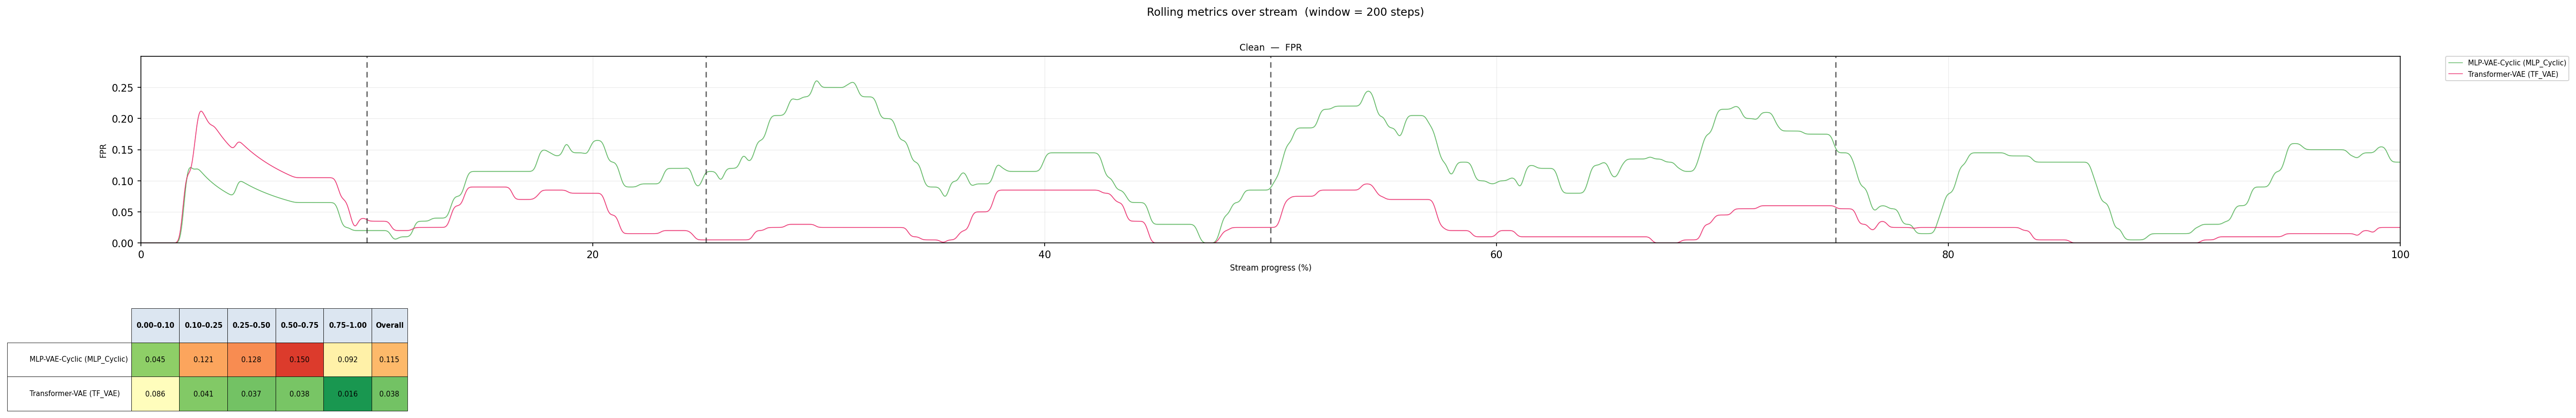

In [9]:
!python scripts/plot_fpr_over_time.py runs/regression/case01_clean_baseline

from IPython.display import Image, display
display(Image(filename="runs/regression/case01_clean_baseline/rolling_metrics.png"))

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every result reported in the thesis. It uses a shorter ERA5 interval and shared reduced-run settings so that readers can execute it on Colab.

Differences from the full thesis metrics are expected. Conclusions should be based on the direction and consistency of the comparison rather than exact numerical agreement.

For the complete experiment definitions, consult the thesis sections associated with Fig 4.1, Fig 4.2, and Table 4.1, together with the YAML configuration files used by this suite.